# Check Unity GT vs SAM3D Body Keypoints

对比 Unity GT character 关键点和 SAM3D Body 预测关键点的 3D 可视化。

- Unity GT：`data_pole_ski/{gender}/{action}/kpt3d/character/frame_XXXXXX.npy`（需绕 X 轴旋转 180°）
- SAM3D Body：`sam3d_body_results/inference/{gender}/{action}/frames/{camera}/XXXXXX_sam3d_body.npz`

In [2]:
import sys
from pathlib import Path

REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from project.map_config import (
    FILTER_SKELETON_CONNECTIONS,
    filter_sam3d_body_kpts,
    filter_unity_kpts,
)

# ── 可调参数 ────────────────────────────────────────────────────────────────
GENDER      = "male"
ACTION      = "Anim_Male_Skier_Idle"
CAMERA      = "capture_L0_A000"   # SAM3D body 子目录
FRAME_IDX   = 0                   # 帧编号（0-based）
# ─────────────────────────────────────────────────────────────────────────────

DATA_ROOT = Path("/workspace/data/skiing_unity_dataset")

unity_char_dir  = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt3d" / "character"
sam3d_body_dir  = DATA_ROOT / "sam3d_body_results/modalities_from_sam3d" / GENDER / ACTION / "kpt3d" / CAMERA

print("Unity GT dir :", unity_char_dir)
print("SAM3D dir    :", sam3d_body_dir)
print("Unity files  :", len(list(unity_char_dir.glob("*.npy"))))
print("SAM3D files  :", len(list(sam3d_body_dir.glob("*.npy"))))

Unity GT dir : /workspace/data/skiing_unity_dataset/data_pole_ski/male/Anim_Male_Skier_Idle/kpt3d/character
SAM3D dir    : /workspace/data/skiing_unity_dataset/sam3d_body_results/modalities_from_sam3d/male/Anim_Male_Skier_Idle/kpt3d/capture_L0_A000
Unity files  : 40
SAM3D files  : 40


In [2]:
def rotate_x_90(pts: np.ndarray) -> np.ndarray:
    """绕 X 轴旋转 90 度（Unity → SAM3D 坐标系）。"""
    rotated = pts.copy()
    x, y, z = rotated[:, 0], rotated[:, 1], rotated[:, 2]
    rotated[:, 0] = x
    rotated[:, 1] = -z
    rotated[:, 2] = y
    return rotated

def rotate_y_flip(pts: np.ndarray) -> np.ndarray:
    """绕 Y 轴翻转（180度旋转）。"""
    flipped = pts.copy()
    flipped[:, 0] *= -1   # x 取反
    return flipped

def load_unity_character(frame_idx: int, flag: str) -> np.ndarray:
    """读取 Unity GT character 关键点并转换到 SAM3D 坐标系，再过滤到 15 关节。"""
    path = unity_char_dir / f"frame_{frame_idx:06d}.npy"
    raw = np.load(path).astype(np.float32)
    raw = rotate_x_90(raw)
    raw = rotate_y_flip(raw)
    return filter_unity_kpts(raw, flag=flag, gender=GENDER)          # [15, 3]


def load_sam3d_body(frame_idx: int) -> np.ndarray:
    """读取 SAM3D body 关键点（kpt3d），过滤到 15 关节。"""
    path = sam3d_body_dir / f"kpt3d_{frame_idx:06d}.npy"
    data = np.load(path, allow_pickle=True)
    raw = np.asarray(data).astype(np.float32)
    if raw.ndim == 3:
        raw = raw[0]           # (1, J, 3) → (J, 3)
    return filter_sam3d_body_kpts(raw)     # [15, 3]


# 加载并打印形状
unity_kpt = load_unity_character(FRAME_IDX, flag="3d")
sam3d_kpt = load_sam3d_body(FRAME_IDX)
print("Unity GT  shape:", unity_kpt.shape)
print("SAM3D body shape:", sam3d_kpt.shape)
print("\nUnity GT (前3关节):\n",  unity_kpt[:3])
print("\nSAM3D body (前3关节):\n", sam3d_kpt[:3])

Unity GT  shape: (15, 3)
SAM3D body shape: (15, 3)

Unity GT (前3关节):
 [[ 0.044201   -0.6214626  -0.6214626 ]
 [-0.02113016 -0.6198027  -0.6198027 ]
 [ 0.1590776  -0.41677594 -0.41677594]]

SAM3D body (前3关节):
 [[ 0.0380973  -1.6116385  -0.13869086]
 [-0.02518368 -1.6198422  -0.14279565]
 [ 0.16889271 -1.3769665  -0.01024644]]


Unity character shape: (96, 3)
Unity pole shape     : (4, 3)
Unity ski shape      : (6, 3)
高亮关节：
 51  Bone_Eye_L
 52  Bone_Eye_R
  4  Upperarm_L
 27  Upperarm_R
  5  lowerarm_l
 28  lowerarm_r
 78  Thigh_L
 87  Thigh_R
 79  calf_l
 88  calf_r
 83  Foot_L
 92  Foot_R
 30  Hand_R
  7  Hand_L
 49  neck_01


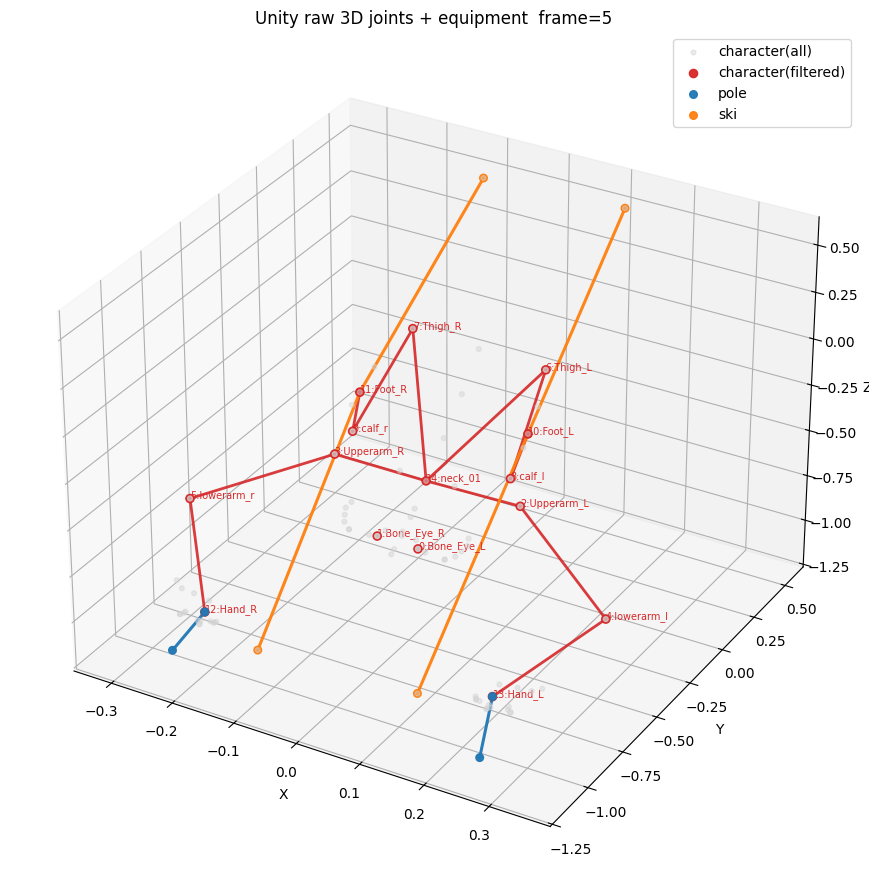

In [11]:
# ── Unity 原始 3D 关节验收可视化（含装备）─────────────────────────────────────
# 目的：先看原始 Unity 3D 是否整体合理，再高亮 15 个过滤关节，并把 ski/pole 一并画出。
char_path = unity_char_dir / f"frame_{FRAME_IDX:06d}.npy"
pole_path = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt3d" / "pole" / f"frame_{FRAME_IDX:06d}.npy"
ski_path  = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt3d" / "ski"  / f"frame_{FRAME_IDX:06d}.npy"

raw_unity = np.load(char_path).astype(np.float32)
raw_unity = rotate_x_90(raw_unity)   # Unity -> SAM3D 坐标系
raw_unity = rotate_y_flip(raw_unity) # Unity -> SAM3D 坐标系

pole_3d = np.load(pole_path).astype(np.float32)
pole_3d = rotate_x_90(pole_3d)
pole_3d = rotate_y_flip(pole_3d)

ski_3d = np.load(ski_path).astype(np.float32)
ski_3d = rotate_x_90(ski_3d)
ski_3d = rotate_y_flip(ski_3d)

from project.map_config import UNITY_MALE_MAPPING as UNITY_MAPPING

selected_ids = [i for i in UNITY_MAPPING.keys()]  # 15 个过滤关节的原始索引
selected_names = [UNITY_MAPPING[i] for i in selected_ids]  # 15 个过滤关节的名称
selected_pts = raw_unity[selected_ids]

print(f"Unity character shape: {raw_unity.shape}")
print(f"Unity pole shape     : {pole_3d.shape}")
print(f"Unity ski shape      : {ski_3d.shape}")
print("高亮关节：")
for jid, name in zip(selected_ids, selected_names):
    print(f"{jid:3d}  {name}")

fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection="3d")
ax.set_title(f"Unity raw 3D joints + equipment  frame={FRAME_IDX}")

# 人体全部关节：浅灰色
ax.scatter(raw_unity[:, 0], raw_unity[:, 1], raw_unity[:, 2], s=12, c="lightgray", alpha=0.45, label="character(all)")

# 高亮过滤关节：红色
ax.scatter(selected_pts[:, 0], selected_pts[:, 1], selected_pts[:, 2], s=35, c="tab:red", alpha=0.95, label="character(filtered)")
for i, j in FILTER_SKELETON_CONNECTIONS:
    if i < selected_pts.shape[0] and j < selected_pts.shape[0]:
        ax.plot(
            [selected_pts[i, 0], selected_pts[j, 0]],
            [selected_pts[i, 1], selected_pts[j, 1]],
            [selected_pts[i, 2], selected_pts[j, 2]],
            color="tab:red", linewidth=2.0, alpha=0.9,
        )

# 装备点：pole / ski
ax.scatter(pole_3d[:, 0], pole_3d[:, 1], pole_3d[:, 2], s=30, c="tab:blue", alpha=0.95, label="pole")
ax.scatter(ski_3d[:, 0], ski_3d[:, 1], ski_3d[:, 2], s=30, c="tab:orange", alpha=0.95, label="ski")

# pole 连线：仅连接把手 -> 杆尖（两根杆）
if len(pole_3d) == 4:
    pole_edges = [(0, 1), (2, 3)]
else:
    pole_edges = [(k, k + 1) for k in range(len(pole_3d) - 1)]

for i, j in pole_edges:
    ax.plot(
        [pole_3d[i, 0], pole_3d[j, 0]],
        [pole_3d[i, 1], pole_3d[j, 1]],
        [pole_3d[i, 2], pole_3d[j, 2]],
        color="tab:blue", linewidth=2.2, alpha=0.95,
    )

# ski 连线：仅连接 center -> front/back（左右各一块）
if len(ski_3d) == 6:
    ski_edges = [(0, 1), (0, 2), (3, 4), (3, 5)]
else:
    ski_edges = [(k, k + 1) for k in range(len(ski_3d) - 1)]

for i, j in ski_edges:
    ax.plot(
        [ski_3d[i, 0], ski_3d[j, 0]],
        [ski_3d[i, 1], ski_3d[j, 1]],
        [ski_3d[i, 2], ski_3d[j, 2]],
        color="tab:orange", linewidth=2.2, alpha=0.95,
    )

for idx, name in enumerate(selected_names):
    ax.text(
        selected_pts[idx, 0], selected_pts[idx, 1], selected_pts[idx, 2],
        f"{idx}:{name}", fontsize=7, color="tab:red",
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


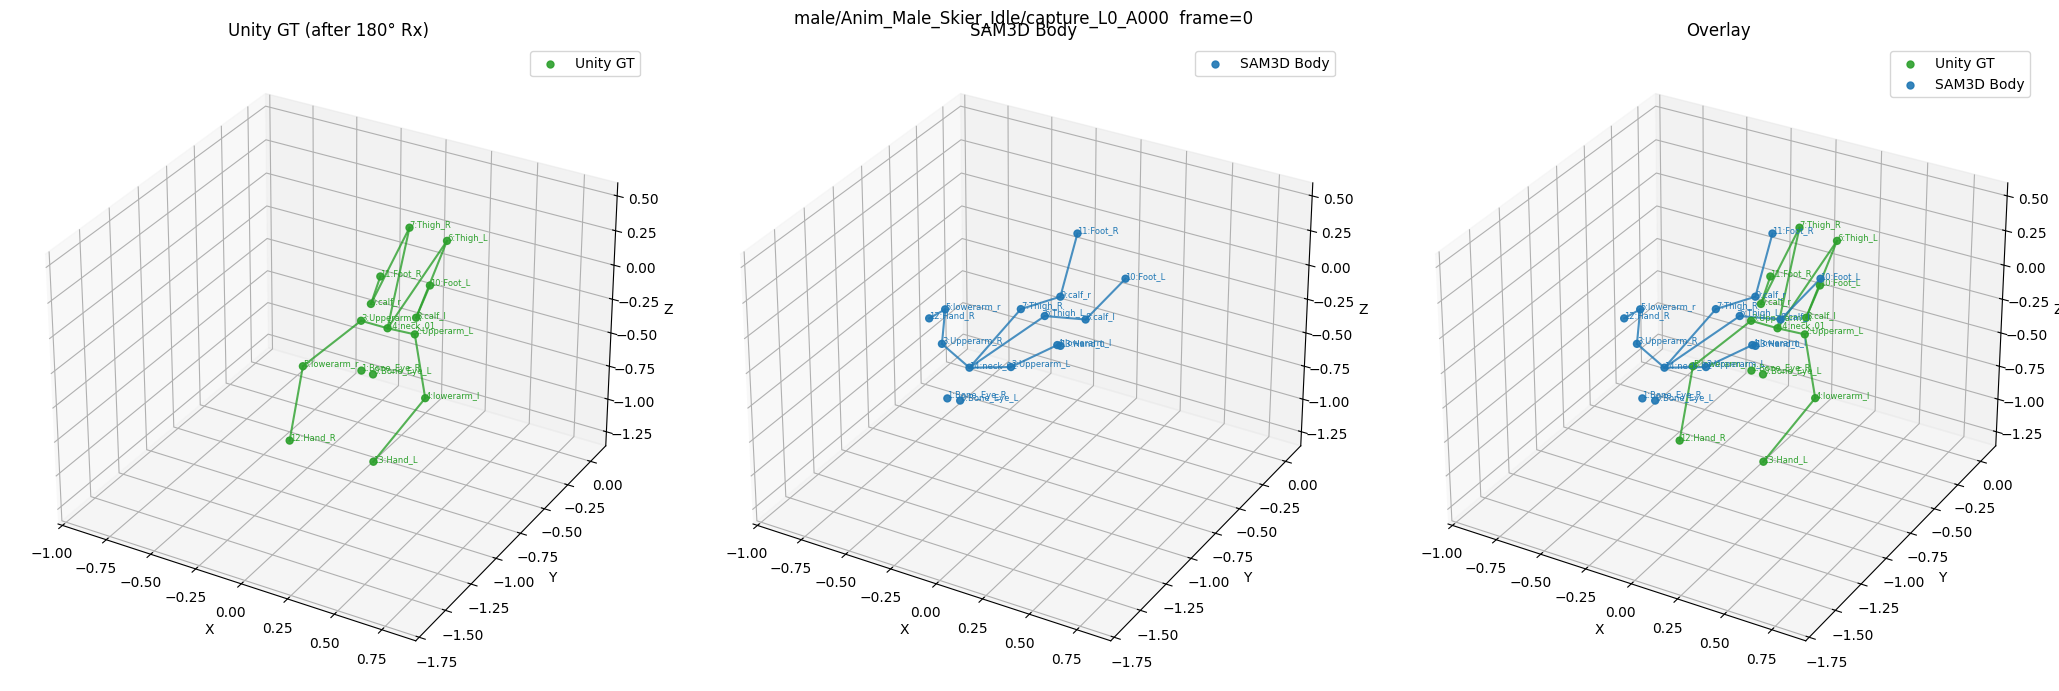

In [4]:
def draw_skeleton_3d(ax, kpts: np.ndarray, color: str, label: str) -> None:
    ax.scatter(kpts[:, 0], kpts[:, 1], kpts[:, 2], s=25, c=color, alpha=0.9, label=label)
    for i, j in FILTER_SKELETON_CONNECTIONS:
        if i < kpts.shape[0] and j < kpts.shape[0]:
            ax.plot(
                [kpts[i, 0], kpts[j, 0]],
                [kpts[i, 1], kpts[j, 1]],
                [kpts[i, 2], kpts[j, 2]],
                color=color, linewidth=1.5, alpha=0.8,
            )


def annotate_kpts_3d(ax, kpts: np.ndarray, names: list[str], color: str) -> None:
    for idx, name in enumerate(names):
        ax.text(
            kpts[idx, 0], kpts[idx, 1], kpts[idx, 2],
            f"{idx}:{name}", fontsize=6, color=color,
        )


def set_equal_axes(ax, all_pts: np.ndarray) -> None:
    mins = all_pts.min(0)
    maxs = all_pts.max(0)
    center = (mins + maxs) * 0.5
    r = float((maxs - mins).max() * 0.6)
    r = max(r, 0.1)
    ax.set_xlim(center[0] - r, center[0] + r)
    ax.set_ylim(center[1] - r, center[1] + r)
    ax.set_zlim(center[2] - r, center[2] + r)

# ── 单帧可视化：独立视角 + 叠加视角 ─────────────────────────────────────────
fig = plt.figure(figsize=(21, 7))
fig.suptitle(f"{GENDER}/{ACTION}/{CAMERA}  frame={FRAME_IDX}")

# unity_kpt = rotate_y_flip(unity_kpt)
all_pts = np.concatenate([unity_kpt, sam3d_kpt], axis=0)

# Panel 1: Unity GT
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
draw_skeleton_3d(ax1, unity_kpt, color="tab:green", label="Unity GT")
annotate_kpts_3d(ax1, unity_kpt, selected_names, color="tab:green")
set_equal_axes(ax1, all_pts)
ax1.set_title("Unity GT (after 180° Rx)")
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")
ax1.legend()

# Panel 2: SAM3D Body
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
draw_skeleton_3d(ax2, sam3d_kpt, color="tab:blue", label="SAM3D Body")
annotate_kpts_3d(ax2, sam3d_kpt, selected_names, color="tab:blue")
set_equal_axes(ax2, all_pts)
ax2.set_title("SAM3D Body")
ax2.set_xlabel("X"); ax2.set_ylabel("Y"); ax2.set_zlabel("Z")
ax2.legend()

# Panel 3: 叠加对比
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
draw_skeleton_3d(ax3, unity_kpt, color="tab:green", label="Unity GT")
draw_skeleton_3d(ax3, sam3d_kpt, color="tab:blue",  label="SAM3D Body")
annotate_kpts_3d(ax3, unity_kpt, selected_names, color="tab:green")
annotate_kpts_3d(ax3, sam3d_kpt, selected_names, color="tab:blue")
set_equal_axes(ax3, all_pts)
ax3.set_title("Overlay")
ax3.set_xlabel("X"); ax3.set_ylabel("Y"); ax3.set_zlabel("Z")
ax3.legend()

plt.tight_layout()
plt.show()

(98, 3)
Unity 2D kpt shape: (15, 2)
SAM3D 2D kpt shape: (15, 2)


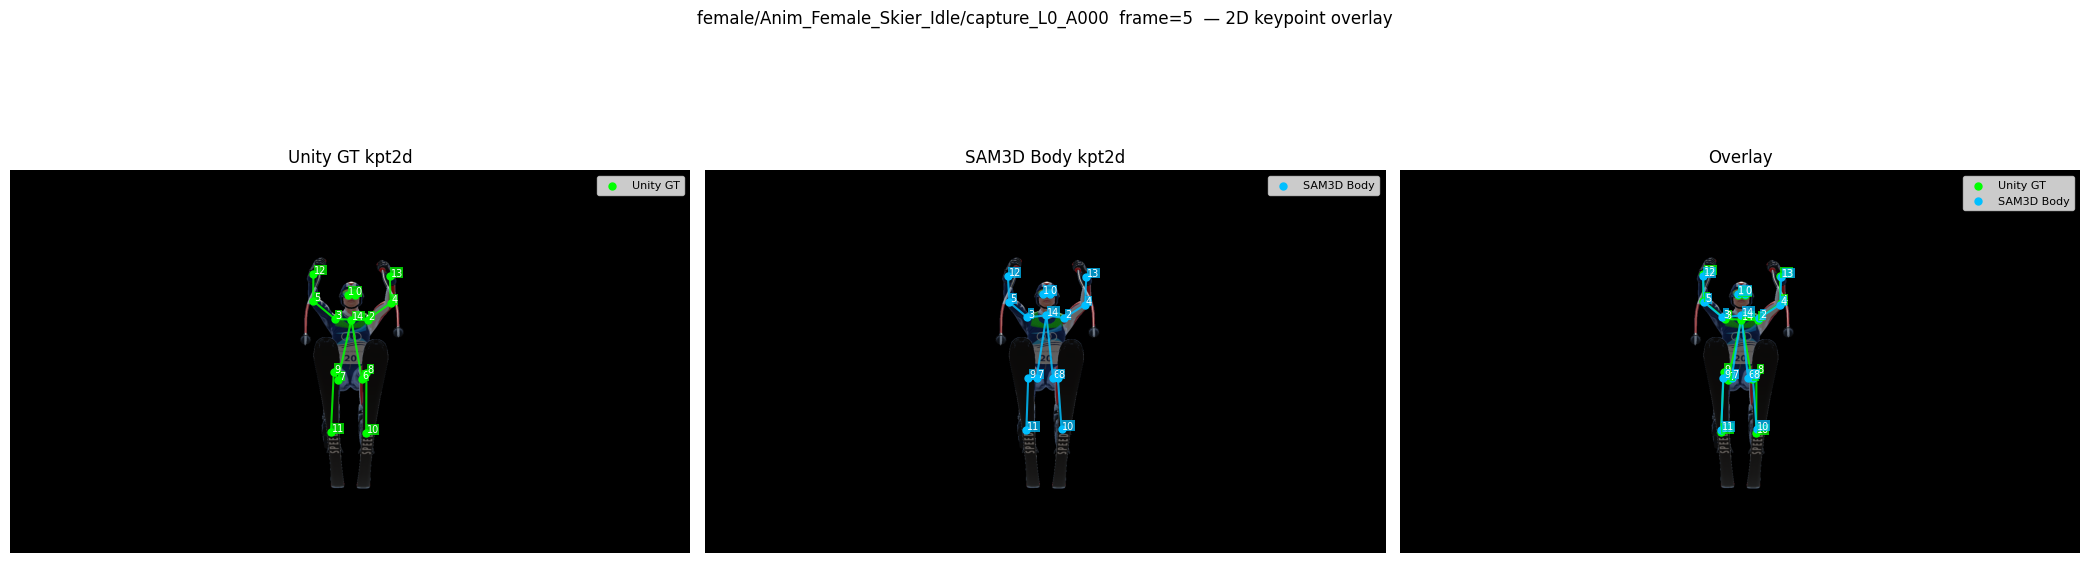

In [5]:
import cv2

# Unity GT kpt2d 子目录名去掉 capture_ 前缀
FRAME_IDX = 5
CAM_SHORT = CAMERA.replace("capture_", "")   # e.g. "L0_A000"

GENDER = "female"
ACTION = "Anim_Female_Skier_Idle"
frame_dir       = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "frames" / CAMERA
unity_kpt2d_dir = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt2d" / CAM_SHORT / "character"
sam3d_kpt2d_dir = DATA_ROOT / "sam3d_body_results/modalities_from_sam3d" / GENDER / ACTION / "kpt2d" / CAMERA

def load_unity_kpt2d(frame_idx: int) -> np.ndarray:
    """读取 Unity GT 2D 关键点并转换到 SAM3D 坐标系，再过滤到 15 关节。"""
    path = unity_kpt2d_dir / f"kpt2d_{frame_idx:06d}.npy"
    raw = np.load(path).astype(np.float32)
    print(raw.shape)
    return filter_unity_kpts(raw, flag="2d", gender=GENDER)          # [15, 2]

def load_sam3d_body_kpt2d(frame_idx: int) -> np.ndarray:
    """读取 SAM3D body 2D 关键点（kpt2d），过滤到 15 关节。"""
    path = sam3d_kpt2d_dir / f"kpt2d_{frame_idx:06d}.npy"
    data = np.load(path, allow_pickle=True)
    raw = np.asarray(data).astype(np.float32)
    if raw.ndim == 3:
        raw = raw[0]           # (1, J, 2) → (J, 2)
    return filter_sam3d_body_kpts(raw)     # [15, 2]

def draw_kpts_on_image(ax, img_rgb: np.ndarray,
                       kpts: np.ndarray, color: str, label: str,
                       radius: int = 5, linewidth: float = 1.5,
                       show_indices: bool = True) -> None:
    """在图像上绘制关键点和骨骼连线。"""
    ax.imshow(img_rgb)
    ax.scatter(kpts[:, 0], kpts[:, 1], s=radius**2, c=color, zorder=3, label=label)
    for i, j in FILTER_SKELETON_CONNECTIONS:
        if i < len(kpts) and j < len(kpts):
            ax.plot(
                [kpts[i, 0], kpts[j, 0]],
                [kpts[i, 1], kpts[j, 1]],
                color=color, linewidth=linewidth, alpha=0.85, zorder=2,
            )

    if show_indices:
        for idx, (x, y) in enumerate(kpts):
            ax.text(
                x + 2,
                y - 2,
                str(idx),
                fontsize=7,
                color="white",
                zorder=4,
                bbox=dict(facecolor=color, edgecolor="none", alpha=0.75, pad=0.2),
            )

    ax.axis("off")


# ── 加载图片和 2D kpt ────────────────────────────────────────────────────────
img_path   = frame_dir / f"frame_{FRAME_IDX:06d}.png"
img_bgr    = cv2.imread(str(img_path))
img_rgb    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

unity_kpt2d = load_unity_kpt2d(frame_idx=FRAME_IDX)[:, :2]  # 可能有多余维度，取前两列
sam3d_kpt2d = load_sam3d_body_kpt2d(frame_idx=FRAME_IDX)

print("Unity 2D kpt shape:", unity_kpt2d.shape)
print("SAM3D 2D kpt shape:", sam3d_kpt2d.shape)

# ── 可视化 ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f"{GENDER}/{ACTION}/{CAMERA}  frame={FRAME_IDX}  — 2D keypoint overlay")

# Panel 1: Unity GT
draw_kpts_on_image(axes[0], img_rgb, unity_kpt2d,
                   color="lime", label="Unity GT", show_indices=True)
axes[0].set_title("Unity GT kpt2d")
axes[0].legend(loc="upper right", fontsize=8)

# Panel 2: SAM3D Body
draw_kpts_on_image(axes[1], img_rgb, sam3d_kpt2d,
                   color="deepskyblue", label="SAM3D Body", show_indices=True)
axes[1].set_title("SAM3D Body kpt2d")
axes[1].legend(loc="upper right", fontsize=8)

# Panel 3: 叠加对比
draw_kpts_on_image(axes[2], img_rgb, unity_kpt2d,
                   color="lime", label="Unity GT", show_indices=True)
draw_kpts_on_image(axes[2], img_rgb, sam3d_kpt2d,
                   color="deepskyblue", label="SAM3D Body", show_indices=True)
axes[2].set_title("Overlay")
axes[2].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()


(97, 3)
Unity 2D kpt shape: (15, 2)
SAM3D 2D kpt shape: (15, 2)


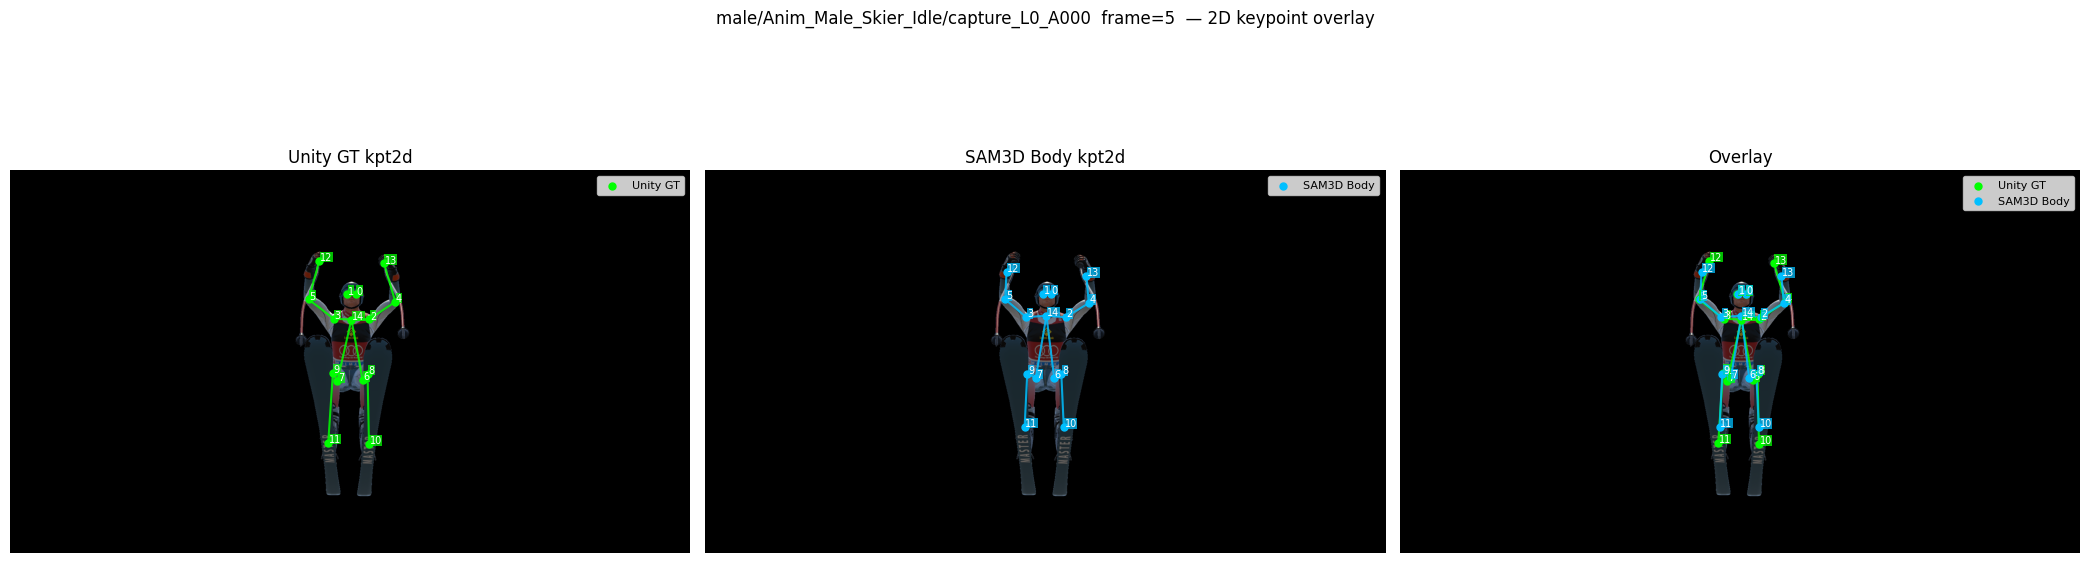

In [6]:
import cv2

# Unity GT kpt2d 子目录名去掉 capture_ 前缀
FRAME_IDX = 5
CAM_SHORT = CAMERA.replace("capture_", "")   # e.g. "L0_A000"

GENDER = "male"
ACTION = "Anim_Male_Skier_Idle"
frame_dir       = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "frames" / CAMERA
unity_kpt2d_dir = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt2d" / CAM_SHORT / "character"
sam3d_kpt2d_dir = DATA_ROOT / "sam3d_body_results/modalities_from_sam3d" / GENDER / ACTION / "kpt2d" / CAMERA

def load_unity_kpt2d(frame_idx: int) -> np.ndarray:
    """读取 Unity GT 2D 关键点并转换到 SAM3D 坐标系，再过滤到 15 关节。"""
    path = unity_kpt2d_dir / f"kpt2d_{frame_idx:06d}.npy"
    raw = np.load(path).astype(np.float32)
    print(raw.shape)
    return filter_unity_kpts(raw, flag="2d", gender=GENDER)          # [15, 2]

def load_sam3d_body_kpt2d(frame_idx: int) -> np.ndarray:
    """读取 SAM3D body 2D 关键点（kpt2d），过滤到 15 关节。"""
    path = sam3d_kpt2d_dir / f"kpt2d_{frame_idx:06d}.npy"
    data = np.load(path, allow_pickle=True)
    raw = np.asarray(data).astype(np.float32)
    if raw.ndim == 3:
        raw = raw[0]           # (1, J, 2) → (J, 2)
    return filter_sam3d_body_kpts(raw)     # [15, 2]

def draw_kpts_on_image(ax, img_rgb: np.ndarray,
                       kpts: np.ndarray, color: str, label: str,
                       radius: int = 5, linewidth: float = 1.5,
                       show_indices: bool = True) -> None:
    """在图像上绘制关键点和骨骼连线。"""
    ax.imshow(img_rgb)
    ax.scatter(kpts[:, 0], kpts[:, 1], s=radius**2, c=color, zorder=3, label=label)
    for i, j in FILTER_SKELETON_CONNECTIONS:
        if i < len(kpts) and j < len(kpts):
            ax.plot(
                [kpts[i, 0], kpts[j, 0]],
                [kpts[i, 1], kpts[j, 1]],
                color=color, linewidth=linewidth, alpha=0.85, zorder=2,
            )

    if show_indices:
        for idx, (x, y) in enumerate(kpts):
            ax.text(
                x + 2,
                y - 2,
                str(idx),
                fontsize=7,
                color="white",
                zorder=4,
                bbox=dict(facecolor=color, edgecolor="none", alpha=0.75, pad=0.2),
            )

    ax.axis("off")


# ── 加载图片和 2D kpt ────────────────────────────────────────────────────────
img_path   = frame_dir / f"frame_{FRAME_IDX:06d}.png"
img_bgr    = cv2.imread(str(img_path))
img_rgb    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

unity_kpt2d = load_unity_kpt2d(frame_idx=FRAME_IDX)[:, :2]  # 可能有多余维度，取前两列
sam3d_kpt2d = load_sam3d_body_kpt2d(frame_idx=FRAME_IDX)

print("Unity 2D kpt shape:", unity_kpt2d.shape)
print("SAM3D 2D kpt shape:", sam3d_kpt2d.shape)

# ── 可视化 ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f"{GENDER}/{ACTION}/{CAMERA}  frame={FRAME_IDX}  — 2D keypoint overlay")

# Panel 1: Unity GT
draw_kpts_on_image(axes[0], img_rgb, unity_kpt2d,
                   color="lime", label="Unity GT", show_indices=True)
axes[0].set_title("Unity GT kpt2d")
axes[0].legend(loc="upper right", fontsize=8)

# Panel 2: SAM3D Body
draw_kpts_on_image(axes[1], img_rgb, sam3d_kpt2d,
                   color="deepskyblue", label="SAM3D Body", show_indices=True)
axes[1].set_title("SAM3D Body kpt2d")
axes[1].legend(loc="upper right", fontsize=8)

# Panel 3: 叠加对比
draw_kpts_on_image(axes[2], img_rgb, unity_kpt2d,
                   color="lime", label="Unity GT", show_indices=True)
draw_kpts_on_image(axes[2], img_rgb, sam3d_kpt2d,
                   color="deepskyblue", label="SAM3D Body", show_indices=True)
axes[2].set_title("Overlay")
axes[2].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

共对比 40 帧（2D）
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
(97, 3)
2D MPJPE (all joints, all frames) = 22.54 px
逐关节平均误差 (px): [ 3.18  3.8   7.33  9.1  16.56 16.59 11.76 13.72 17.12 18.75 42.91 45.01
 60.53 61.44 10.27]


/tmp/ipykernel_3485618/3164274805.py:37: UserWarning: Glyph 36880 (\N{CJK UNIFIED IDEOGRAPH-9010}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3485618/3164274805.py:37: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3485618/3164274805.py:37: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3485618/3164274805.py:37: UserWarning: Glyph 33410 (\N{CJK UNIFIED IDEOGRAPH-8282}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3485618/3164274805.py:37: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3485618/3164274805.py:37: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3485618/3164274805.py:37: UserWarning: Glyph 35823 (\N{CJK UN

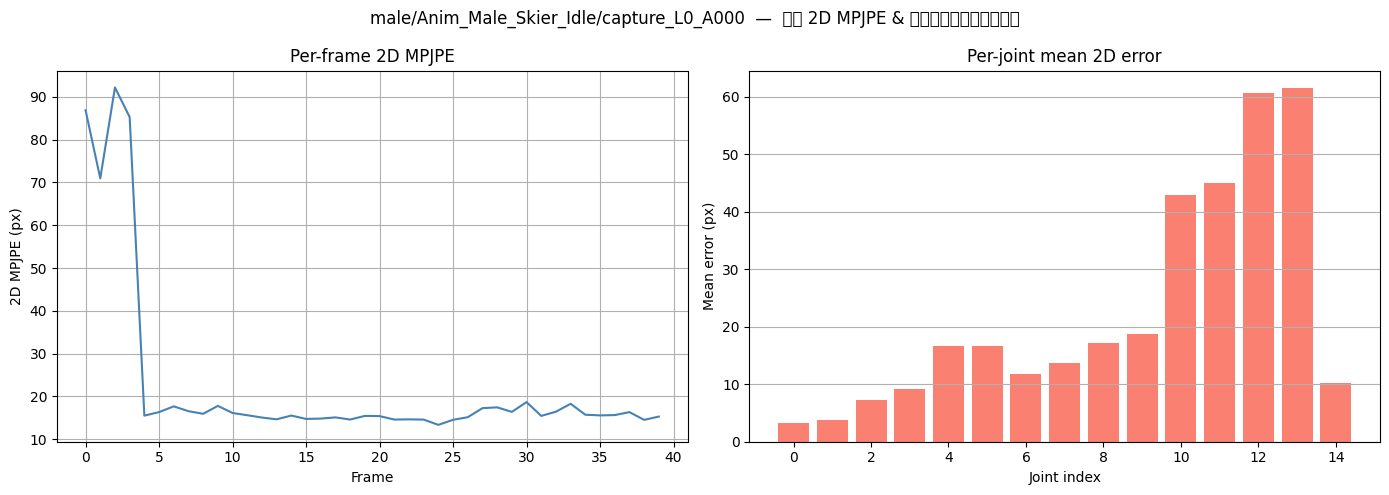

In [7]:
# ── 多帧 2D MPJPE ────────────────────────────────────────────────────────────
unity_kpt2d_files = sorted((DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt2d" / CAM_SHORT / "character").glob("kpt2d_*.npy"))
sam3d_kpt2d_files = sorted((DATA_ROOT / "sam3d_body_results/modalities_from_sam3d" / GENDER / ACTION / "kpt2d" / CAMERA).glob("kpt2d_*.npy"))

n_frames_2d = min(len(unity_kpt2d_files), len(sam3d_kpt2d_files))
print(f"共对比 {n_frames_2d} 帧（2D）")

all_errors_2d = []   # [N, 15]
for i in range(n_frames_2d):
    u2 = load_unity_kpt2d(i)[:, :2]    # [15, 2]
    s2 = load_sam3d_body_kpt2d(i)  # [15, 2]
    err = np.linalg.norm(u2 - s2, axis=-1)   # [15]  (pixel distance)
    all_errors_2d.append(err)

all_errors_2d  = np.stack(all_errors_2d, axis=0)   # [N, 15]
mean_per_joint_2d = all_errors_2d.mean(axis=0)
mpjpe_2d = all_errors_2d.mean()

print(f"2D MPJPE (all joints, all frames) = {mpjpe_2d:.2f} px")
print(f"逐关节平均误差 (px): {np.round(mean_per_joint_2d, 2)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"{GENDER}/{ACTION}/{CAMERA}  —  逐帧 2D MPJPE & 逐关节平均误差（像素）")

axes[0].plot(all_errors_2d.mean(axis=1), color="steelblue")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("2D MPJPE (px)")
axes[0].set_title("Per-frame 2D MPJPE")
axes[0].grid(True)

axes[1].bar(range(15), mean_per_joint_2d, color="salmon")
axes[1].set_xlabel("Joint index")
axes[1].set_ylabel("Mean error (px)")
axes[1].set_title("Per-joint mean 2D error")
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()


共对比 40 帧
MPJPE (all joints, all frames) = 0.8961


/tmp/ipykernel_3485618/2992229732.py:39: UserWarning: Glyph 36880 (\N{CJK UNIFIED IDEOGRAPH-9010}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3485618/2992229732.py:39: UserWarning: Glyph 24103 (\N{CJK UNIFIED IDEOGRAPH-5E27}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3485618/2992229732.py:39: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3485618/2992229732.py:39: UserWarning: Glyph 33410 (\N{CJK UNIFIED IDEOGRAPH-8282}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3485618/2992229732.py:39: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3485618/2992229732.py:39: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3485618/2992229732.py:39: UserWarning: Glyph 35823 (\N{CJK UN

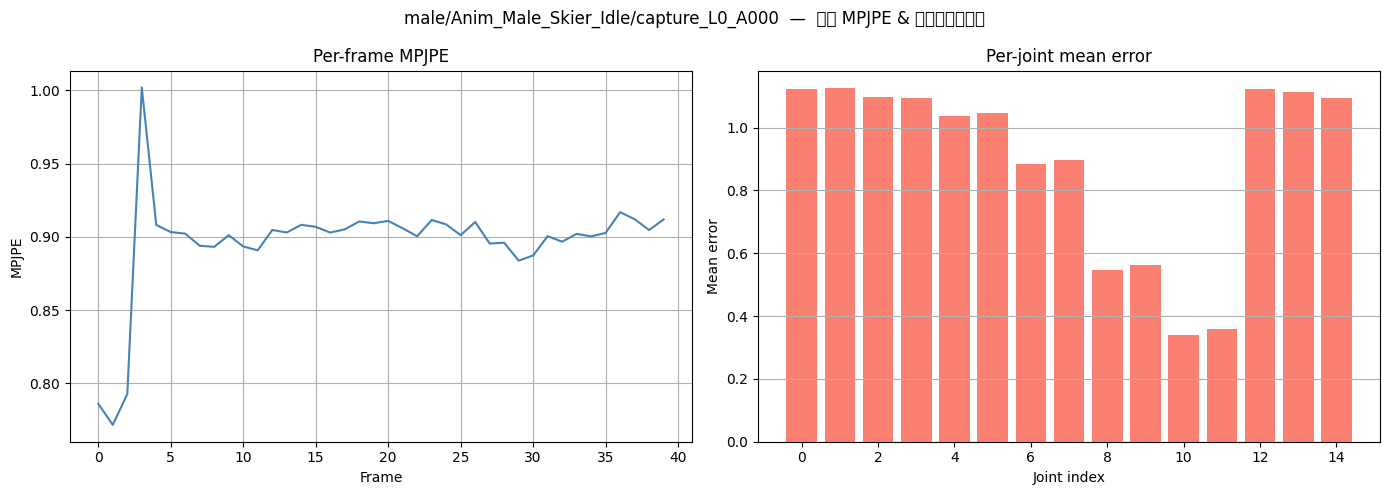

In [8]:
# ── 多帧 MPJPE 逐关节误差 ────────────────────────────────────────────────────
unity_files = sorted(unity_char_dir.glob("frame_*.npy"))
sam3d_files = sorted(sam3d_body_dir.glob("kpt3d_*.npy"))

n_frames = min(len(unity_files), len(sam3d_files))
print(f"共对比 {n_frames} 帧")

all_errors = []   # [N, 15]
for i in range(n_frames):
    u = load_unity_character(i, flag="3d")  # [15, 3]
    s = load_sam3d_body(i)
    err = np.linalg.norm(u - s, axis=-1)   # [15]
    all_errors.append(err)

all_errors = np.stack(all_errors, axis=0)  # [N, 15]

mean_per_joint = all_errors.mean(axis=0)
mpjpe = all_errors.mean()

print(f"MPJPE (all joints, all frames) = {mpjpe:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"{GENDER}/{ACTION}/{CAMERA}  —  逐帧 MPJPE & 逐关节平均误差")

# 逐帧 MPJPE
axes[0].plot(all_errors.mean(axis=1), color="steelblue")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("MPJPE")
axes[0].set_title("Per-frame MPJPE")
axes[0].grid(True)

# 逐关节平均误差
axes[1].bar(range(15), mean_per_joint, color="salmon")
axes[1].set_xlabel("Joint index")
axes[1].set_ylabel("Mean error")
axes[1].set_title("Per-joint mean error")
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

char kpt2d: (15, 2)  pole: (4, 3)  ski: (6, 3)


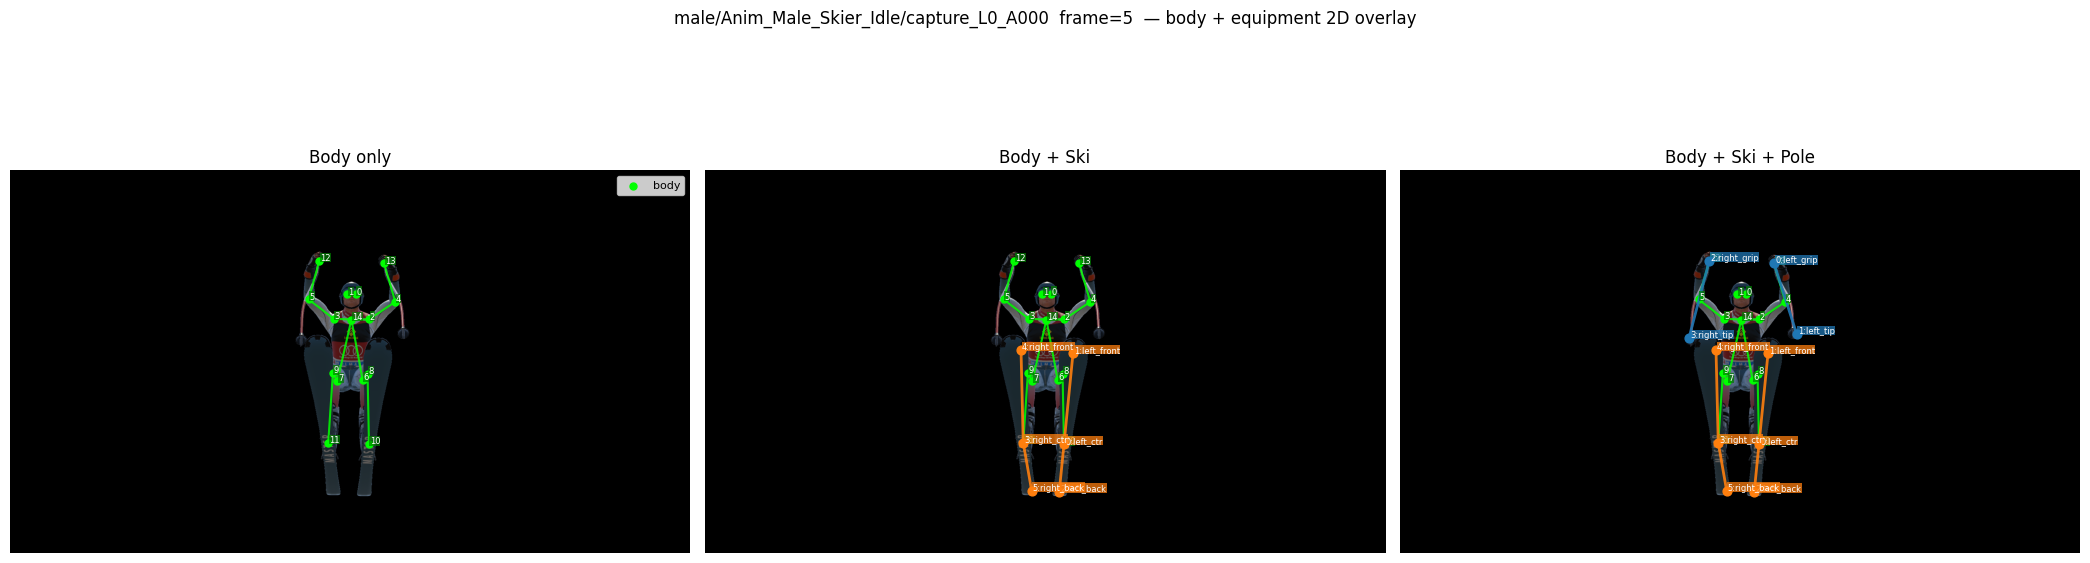

In [3]:

# ── 装备 2D 关键点叠加到图片 ─────────────────────────────────────────────────
# Unity kpt2d/pole: (4, 3)  [x, y, vis]  顺序: left_grip, left_tip, right_grip, right_tip
# Unity kpt2d/ski : (6, 3)  [x, y, vis]  顺序: left_center, left_front, left_back, right_center, right_front, right_back
# pole 连线: (0,1) 左杆, (2,3) 右杆
# ski  连线: (0,1), (0,2) 左板, (3,4), (3,5) 右板

FRAME_IDX = 5
GENDER  = "male"
ACTION  = "Anim_Male_Skier_Idle"
CAMERA  = "capture_L0_A000"
CAM_SHORT = CAMERA.replace("capture_", "")

frame_dir         = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "frames" / CAMERA
unity_kpt2d_char  = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt2d" / CAM_SHORT / "character"
unity_kpt2d_pole  = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt2d" / CAM_SHORT / "pole"
unity_kpt2d_ski   = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt2d" / CAM_SHORT / "ski"

import cv2

def load_equip_kpt2d(equip_dir: Path, frame_idx: int) -> np.ndarray:
    path = equip_dir / f"kpt2d_{frame_idx:06d}.npy"
    return np.load(path).astype(np.float32)  # (N, 3)

POLE_EDGES = [(0, 1), (2, 3)]
SKI_EDGES  = [(0, 1), (0, 2), (3, 4), (3, 5)]
POLE_NAMES = ["left_grip", "left_tip", "right_grip", "right_tip"]
SKI_NAMES  = ["left_ctr", "left_front", "left_back", "right_ctr", "right_front", "right_back"]


def draw_equip_on_ax(ax, kpts: np.ndarray, edges: list, names: list,
                     color: str, linewidth: float = 2.0) -> None:
    """在 matplotlib ax 上绘制装备关键点和连线（vis>0 才画）。"""
    vis = kpts[:, 2] if kpts.shape[1] >= 3 else np.ones(len(kpts))
    xy  = kpts[:, :2]
    for i, j in edges:
        if vis[i] > 0 and vis[j] > 0:
            ax.plot([xy[i, 0], xy[j, 0]], [xy[i, 1], xy[j, 1]],
                    color=color, linewidth=linewidth, alpha=0.9, zorder=3)
    for idx in range(len(xy)):
        if vis[idx] > 0:
            ax.scatter(xy[idx, 0], xy[idx, 1], s=40, c=color, zorder=4)
            ax.text(xy[idx, 0] + 3, xy[idx, 1] - 3,
                    f"{idx}:{names[idx]}", fontsize=6, color="white", zorder=5,
                    bbox=dict(facecolor=color, edgecolor="none", alpha=0.75, pad=0.2))


# ── 加载数据 ─────────────────────────────────────────────────────────────────
img_bgr  = cv2.imread(str(frame_dir / f"frame_{FRAME_IDX:06d}.png"))
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

from project.map_config import UNITY_MALE_MAPPING as UNITY_MAP_MALE, filter_unity_kpts
char_kpt2d = filter_unity_kpts(
    np.load(unity_kpt2d_char / f"kpt2d_{FRAME_IDX:06d}.npy").astype(np.float32),
    flag="2d", gender=GENDER
)[:, :2]  # (15, 2)

pole_kpt2d = load_equip_kpt2d(unity_kpt2d_pole, FRAME_IDX)  # (4, 3)
ski_kpt2d  = load_equip_kpt2d(unity_kpt2d_ski,  FRAME_IDX)  # (6, 3)

print(f"char kpt2d: {char_kpt2d.shape}  pole: {pole_kpt2d.shape}  ski: {ski_kpt2d.shape}")

# ── 可视化 ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f"{GENDER}/{ACTION}/{CAMERA}  frame={FRAME_IDX}  — body + equipment 2D overlay")

titles = ["Body only", "Body + Ski", "Body + Ski + Pole"]
for ax, title in zip(axes, titles):
    ax.imshow(img_rgb)
    ax.axis("off")
    ax.set_title(title)
    # 人体骨架
    ax.scatter(char_kpt2d[:, 0], char_kpt2d[:, 1], s=25, c="lime", zorder=3, label="body")
    for i, j in FILTER_SKELETON_CONNECTIONS:
        if i < len(char_kpt2d) and j < len(char_kpt2d):
            ax.plot([char_kpt2d[i, 0], char_kpt2d[j, 0]],
                    [char_kpt2d[i, 1], char_kpt2d[j, 1]],
                    color="lime", linewidth=1.5, alpha=0.85, zorder=2)
    for idx, (x, y) in enumerate(char_kpt2d):
        ax.text(x + 2, y - 2, str(idx), fontsize=6, color="white", zorder=4,
                bbox=dict(facecolor="green", edgecolor="none", alpha=0.7, pad=0.2))

# Panel 2+3: ski
for ax in axes[1:]:
    draw_equip_on_ax(ax, ski_kpt2d,  SKI_EDGES,  SKI_NAMES,  color="tab:orange")

# Panel 3: pole
draw_equip_on_ax(axes[2], pole_kpt2d, POLE_EDGES, POLE_NAMES, color="tab:blue")

axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()
